# Particle Phase Inference: Applying the Trained Model to New Flight Data

This notebook applies the hybrid CNN (image + arearatio feature) trained in
`particle_classification_final.ipynb` to new, unlabeled flight data from the 2D-S probe.

**Workflow:**
1. Load the saved phase model, feature scaler, and (optionally) the donut filter model
2. Load new PBP netCDF files for a new flight
3. Apply the same heuristic quality filters used during training
4. Extract 128×128 particle images in memory
5. *(Optional)* Run the CNN donut filter — remove remaining donut artifacts before phase classification
6. Run phase inference on non-donut particles → Liquid / Solid predictions + confidence
7. Export results to CSV and generate time-series visualizations
8. *(Optional)* Evaluate accuracy if temperature labels are available

**Prerequisites:**
- Run `particle_classification_final.ipynb` → produces `ablation_results/hybrid_seed42.keras` and `data_splits_ablation/data_splits_seed42.pkl`
- *(If using donut filter)* Run `donut_filter_training.ipynb` → produces `donut_filter_results/donut_filter_model.keras`

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import tensorflow as tf
import pickle
import os
from pathlib import Path
from skimage.transform import resize

print(f"TensorFlow {tf.__version__}")
print(f"NumPy {np.__version__}")

TensorFlow 2.20.0
NumPy 2.0.2


## 2. Configuration

**Edit this cell before running the notebook.**

In [2]:
# ── Google Colab setup ────────────────────────────────────────────────────────
# On Colab: run this cell. Locally: base_path stays './'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/GEOG5100/aircraft_ml/'
    IN_COLAB = True
except ImportError:
    base_path = './'
    IN_COLAB = False

print(f"{'Colab' if IN_COLAB else 'Local'} mode  |  base_path = {base_path}")


Mounted at /content/drive
Colab mode  |  base_path = /content/drive/MyDrive/GEOG5100/aircraft_ml/


In [3]:
# ── Google Colab setup ────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/GEOG5100/aircraft_ml/'
    IN_COLAB = True
except ImportError:
    base_path = './'
    IN_COLAB = False

print(f"{'Colab' if IN_COLAB else 'Local'} mode  |  base_path = {base_path}")

NEW_PBP_FILES    = [
    os.path.join(base_path, 'Data/20250524_022503_F2DS_V.pbp.nc'),
   # os.path.join(base_path, 'Data/new_flight_F2DS_H.pbp.nc'),
]
NEW_ENV_FILE     = os.path.join(base_path, 'Data/20250524_022503_F2DS_V.pbp.nc')
MODEL_PATH       = os.path.join(base_path, 'hybrid_synthetic_results/hybrid_synthetic_model.keras')
DATA_SPLITS_PATH = os.path.join(base_path, 'hybrid_synthetic_results/scaler.pkl')
DONUT_MODEL_PATH = os.path.join(base_path, 'donut_filter_results/donut_filter_model.keras')
OUTPUT_DIR       = os.path.join(base_path, 'inference_results')


# Date of the new flight (used to convert probe seconds-from-midnight to UTC)
FLIGHT_DATE = '2025-05-24'  # ← update to the new flight date (YYYY-MM-DD)

# ── Donut filter (produced by donut_filter_training.ipynb) ────────────────────
# Set True to run a CNN donut filter before phase classification.
# Particles predicted as donuts are excluded from phase classification and
# labelled 'Donut' (phase=2) in the output CSV.
DONUT_FILTER     = True
DONUT_THRESHOLD  = 0.5   # P(donut) threshold — increase to be more conservative


# ── Evaluation ────────────────────────────────────────────────────────────────
# Set True only if NEW_ENV_FILE has ATX temperature data covering both
# warm (>= 1 °C) and cold (<= -40 °C) portions of the flight
HAS_GROUND_TRUTH = False

# ──────────────────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs          → {OUTPUT_DIR}")
print(f"Donut filter     : {'ENABLED  (threshold=' + str(DONUT_THRESHOLD) + ')' if DONUT_FILTER else 'disabled'}")
print(f"Ground truth eval: {'enabled' if HAS_GROUND_TRUTH else 'disabled'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab mode  |  base_path = /content/drive/MyDrive/GEOG5100/aircraft_ml/
Outputs          → /content/drive/MyDrive/GEOG5100/aircraft_ml/inference_results
Donut filter     : ENABLED  (threshold=0.5)
Ground truth eval: disabled


## 3. Helper Functions

These replicate the preprocessing logic from `process_particle_data.py` exactly.
The quality-filter thresholds below must match the values used during training.

In [4]:
# ── Quality filter thresholds (must match training) ───────────────────────────
MIN_DIAMETER         = 100    # µm — minimum particle diameter
AREARATIO_MAX        = 0.95   # reject near-perfect rectangles
ASPECTRATIO_MIN      = 0.90   # reject near-perfect rectangles
ASPECTRATIO_LINE     = 0.20   # reject line-like particles
VOID_THRESHOLD       = 0.05   # reject hollow/donut particles (heuristic)
MIN_AREARATIO_FILLED = 0.90   # rectangle fill threshold

# Temperature thresholds (used only when HAS_GROUND_TRUTH = True)
LIQUID_TEMP_THRESHOLD = 1.0    # °C
SOLID_TEMP_THRESHOLD  = -40.0  # °C

IMAGE_SIZE = 128
PHASE_NAMES = {0: 'Liquid', 1: 'Solid', 2: 'Donut'}


def load_pbp_data(pbp_file, flight_date):
    """Load a PBP netCDF file and attach a UTC time coordinate."""
    print(f"  Loading {Path(pbp_file).name} ...")
    ds = xr.open_dataset(pbp_file, decode_times=False)
    origin = np.datetime64(f'{flight_date}T00:00:00')
    utc_times = origin + ds['probetime'].astype('timedelta64[s]')
    ds['Time'] = utc_times
    ds = ds.assign_coords(particle_idx_seq=("Time", np.arange(ds.dims["Time"])))
    print(f"    → {ds.dims['Time']:,} particles")
    return ds


def create_exclusion_mask(ds):
    """Boolean exclusion mask (True = remove). Mirrors training exactly."""
    void_index  = (ds['areafilled'] - ds['area']) / ds['areafilled']
    donut_mask  = void_index >= VOID_THRESHOLD
    square_mask = (ds['arearatiofilled'] > AREARATIO_MAX) & (ds['aspectratio'] > ASPECTRATIO_MIN)
    line_mask   = ds['aspectratio'] < ASPECTRATIO_LINE
    rect_mask   = (ds['arearatiofilled'] >= MIN_AREARATIO_FILLED) & (ds['aspectratio'] < 0.15)
    size_mask   = ds['diam'] <= MIN_DIAMETER
    return donut_mask | square_mask | line_mask | size_mask | rect_mask


def apply_quality_filters(ds):
    """Apply heuristic quality filters and return the filtered dataset."""
    n_orig = ds.dims['Time']
    mask = create_exclusion_mask(ds)
    ds_filtered = ds.isel(Time=~mask.values)
    n_filt = ds_filtered.dims['Time']
    print(f"    Heuristic filter: kept {n_filt:,} / {n_orig:,} particles "
          f"({n_filt / n_orig * 100:.1f}%)")
    return ds_filtered


def extract_particle_image(ds, particle_index, target_size=IMAGE_SIZE):
    """
    Extract and standardize a single particle image as a numpy array.

    Mirrors plot_particle_standardized() from process_particle_data.py but
    returns a float32 array (target_size × target_size) instead of saving to disk.
    Returns None if the particle image cannot be extracted.
    """
    try:
        r0 = int(ds['starty'].values[particle_index])
        r1 = int(ds['stopy'].values[particle_index])
        c0 = int(ds['startx'].values[particle_index])
        c1 = int(ds['stopx'].values[particle_index])
    except Exception:
        return None

    cropped = ds['image'].values[r0:r1, c0:c1]
    cropped = (cropped > 0).astype(np.uint8)

    rows_ok = np.any(cropped == 1, axis=1)
    cols_ok = np.any(cropped == 1, axis=0)
    if not np.any(rows_ok) or not np.any(cols_ok):
        return None

    cropped = cropped[rows_ok][:, cols_ok]
    H, W = cropped.shape
    scale = float(target_size) / float(max(H, W))
    new_H = max(1, int(round(H * scale)))
    new_W = max(1, int(round(W * scale)))

    resized = resize(cropped, (new_H, new_W), order=0,
                     anti_aliasing=False, preserve_range=True)
    resized = (resized > 0.5).astype(np.uint8)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)
    pad_y = (target_size - new_H) // 2
    pad_x = (target_size - new_W) // 2
    canvas[pad_y:pad_y + new_H, pad_x:pad_x + new_W] = resized
    canvas = 1 - canvas   # invert to match training convention (white background)
    return canvas.astype(np.float32)


def extract_particles_for_inference(ds, feature_columns, probe_name=''):
    """
    Iterate over all particles in a filtered PBP dataset and extract images + features.

    Parameters
    ----------
    ds              : filtered xarray Dataset
    feature_columns : list of feature names to extract (must match training order)
    probe_name      : string label for progress messages

    Returns
    -------
    images       : ndarray (N, 128, 128, 1)              float32
    features     : ndarray (N, len(feature_columns))     float32
    times        : ndarray (N,)                          datetime64
    particle_ids : ndarray (N,)                          int64
    """
    n = ds.dims['Time']
    images, features, times, particle_ids = [], [], [], []
    skipped = 0

    feat_vals    = {col: ds[col].values for col in feature_columns}
    t_vals       = ds['Time'].values
    pid_vals     = ds['particle_idx_seq'].values

    for i in range(n):
        img = extract_particle_image(ds, i)
        if img is None:
            skipped += 1
            continue
        images.append(img[..., np.newaxis])   # add channel dim → (128, 128, 1)
        features.append([float(feat_vals[col][i]) for col in feature_columns])
        times.append(t_vals[i])
        particle_ids.append(int(pid_vals[i]))

        if (i + 1) % 1000 == 0:
            print(f"    [{probe_name}] {i + 1:,} / {n:,} processed ...")

    print(f"    [{probe_name}] Done — extracted {len(images):,}, skipped {skipped:,}")
    return (
        np.array(images,       dtype=np.float32),
        np.array(features,     dtype=np.float32),
        np.array(times),
        np.array(particle_ids, dtype=np.int64),
    )


print("Helper functions defined.")

Helper functions defined.


## 4. Load Models

In [18]:
# ── Phase model ───────────────────────────────────────────────────────────────
assert os.path.exists(MODEL_PATH), (
    f"Phase model not found: '{MODEL_PATH}'.\n"
    "Run particle_classification_final.ipynb first."
)
assert os.path.exists(DATA_SPLITS_PATH), (
    f"Data splits not found: '{DATA_SPLITS_PATH}'.\n"
    "Run particle_classification_final.ipynb first."
)

print("Loading phase classifier ...")
phase_model = tf.keras.models.load_model(MODEL_PATH)
phase_model.summary()

print("\nLoading feature scaler ...")
with open(DATA_SPLITS_PATH, 'rb') as f:
    data_splits = pickle.load(f)
scaler          = data_splits['scaler']
feature_columns = data_splits['feature_columns']
print(f"  Features : {feature_columns}")
print(f"  Mean     : {scaler.mean_}")
print(f"  Std      : {scaler.scale_}")

# ── Donut filter model (optional) ─────────────────────────────────────────────
if DONUT_FILTER:
    assert os.path.exists(DONUT_MODEL_PATH), (
        f"Donut model not found: '{DONUT_MODEL_PATH}'.\n"
        "Run donut_filter_training.ipynb first."
    )
    print("\nLoading donut filter model ...")
    donut_model = tf.keras.models.load_model(DONUT_MODEL_PATH)
    print(f"  Donut threshold : {DONUT_THRESHOLD}")
    print(f"  Particles with P(donut) >= {DONUT_THRESHOLD} will be labelled 'Donut'")
    print(f"  and excluded from phase classification.")
else:
    donut_model = None
    print("\nDonut filter: DISABLED")

Loading phase classifier ...


Model: "Hybrid_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        384 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embeddin1   │ (None, 64)        │      8,256 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ feature_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embedding   │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_features        │ (None, 32)        │      1,056 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ feature_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ cnn_features[0][… │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_gate (Dense) │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 112,712 (440.29 KB)

 Trainable params: 37,538 (146.63 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 75,078 (293.28 KB)


Loading feature scaler ...
  Features : ['arearatio', 'aspectratio']
  Mean     : [0.61241988 0.62868476]
  Std      : [0.22936084 0.24090346]

Loading donut filter model ...
  Donut threshold : 0.5
  Particles with P(donut) >= 0.5 will be labelled 'Donut'
  and excluded from phase classification.


## 5. Load and Preprocess New Flight Data

In [19]:
all_images, all_features, all_times, all_particle_ids, all_probes = [], [], [], [], []

for pbp_file in NEW_PBP_FILES:
    if not os.path.exists(pbp_file):
        print(f"WARNING: {pbp_file} not found — skipping.")
        continue

    probe_name = Path(pbp_file).stem.split('_')[-1]   # e.g. 'V' or 'H'
    print(f"\n{'='*60}")
    print(f"Probe {probe_name}: {pbp_file}")

    ds = load_pbp_data(pbp_file, FLIGHT_DATE)
    ds_filtered = apply_quality_filters(ds)

    print("    Extracting images and features ...")
    imgs, feats, times, pids = extract_particles_for_inference(
        ds_filtered, feature_columns, probe_name
    )

    all_images.append(imgs)
    all_features.append(feats)
    all_times.append(times)
    all_particle_ids.append(pids)
    all_probes.extend([probe_name] * len(imgs))

    ds.close()

if not all_images:
    raise RuntimeError("No PBP files were loaded. Check NEW_PBP_FILES paths.")

images       = np.concatenate(all_images,       axis=0)
features     = np.concatenate(all_features,     axis=0)
times        = np.concatenate(all_times,        axis=0)
particle_ids = np.concatenate(all_particle_ids, axis=0)
probes       = np.array(all_probes)
n            = len(images)

# Keep arearatio as a 1-D array for downstream visualizations
ar_col     = feature_columns.index('arearatio')
arearatios = features[:, ar_col]

print(f"\n{'='*60}")
print(f"Total particles after heuristic filtering : {n:,}")
print(f"Image array shape                         : {images.shape}")
print(f"Feature array shape                       : {features.shape}")


Probe V.pbp: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/20250524_022503_F2DS_V.pbp.nc
  Loading 20250524_022503_F2DS_V.pbp.nc ...


/tmp/ipykernel_2916/1302169799.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.assign_coords(particle_idx_seq=("Time", np.arange(ds.dims["Time"])))
/tmp/ipykernel_2916/1302169799.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"    → {ds.dims['Time']:,} particles")
/tmp/ipykernel_2916/1302169799.py:42: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_orig = ds.dims['T

    → 3,754,562 particles


/tmp/ipykernel_2916/1302169799.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_filt = ds_filtered.dims['Time']
/tmp/ipykernel_2916/1302169799.py:110: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n = ds.dims['Time']


    Heuristic filter: kept 76,708 / 3,754,562 particles (2.0%)
    Extracting images and features ...
    [V.pbp] 1,000 / 76,708 processed ...
    [V.pbp] 2,000 / 76,708 processed ...
    [V.pbp] 3,000 / 76,708 processed ...
    [V.pbp] 4,000 / 76,708 processed ...
    [V.pbp] 5,000 / 76,708 processed ...
    [V.pbp] 6,000 / 76,708 processed ...
    [V.pbp] 7,000 / 76,708 processed ...
    [V.pbp] 8,000 / 76,708 processed ...
    [V.pbp] 9,000 / 76,708 processed ...
    [V.pbp] 10,000 / 76,708 processed ...
    [V.pbp] 11,000 / 76,708 processed ...
    [V.pbp] 12,000 / 76,708 processed ...
    [V.pbp] 13,000 / 76,708 processed ...
    [V.pbp] 14,000 / 76,708 processed ...
    [V.pbp] 15,000 / 76,708 processed ...
    [V.pbp] 16,000 / 76,708 processed ...
    [V.pbp] 17,000 / 76,708 processed ...
    [V.pbp] 18,000 / 76,708 processed ...
    [V.pbp] 19,000 / 76,708 processed ...
    [V.pbp] 20,000 / 76,708 processed ...
    [V.pbp] 21,000 / 76,708 processed ...
    [V.pbp] 22,000 / 76,7

## 6. Run Inference

**Step 1 (if `DONUT_FILTER = True`):** CNN donut filter — flags remaining donut artifacts  
**Step 2:** Phase classifier — labels non-donut particles as Liquid or Solid

In [20]:
INFER_BATCH = 64

# ── Step 1: Donut filter ───────────────────────────────────────────────────────
donut_probs = np.zeros(n, dtype=np.float32)   # P(donut) for each particle

if DONUT_FILTER and donut_model is not None:
    print("Step 1: Running donut filter ...")
    for start in range(0, n, INFER_BATCH):
        end = min(start + INFER_BATCH, n)
        donut_probs[start:end] = donut_model.predict(
            images[start:end], verbose=0
        ).ravel()
        if (start // INFER_BATCH) % 20 == 0:
            print(f"  {end:,} / {n:,}")

    is_donut = donut_probs >= DONUT_THRESHOLD
    print(f"  Donuts detected            : {is_donut.sum():,} ({is_donut.mean()*100:.1f}%)")
    print(f"  Passed to phase classifier : {(~is_donut).sum():,}")
else:
    is_donut = np.zeros(n, dtype=bool)
    print("Step 1: Donut filter disabled — all particles passed to phase classifier.")

# ── Step 2: Phase classification on non-donut particles ───────────────────────
# Scale all feature columns together (matches how the scaler was fit during training)
features_scaled = scaler.transform(features).astype(np.float32)

# Allocate output arrays (donut particles stay at 0.0 — overwritten with NaN later)
phase_probs = np.zeros((n, 2), dtype=np.float32)

non_donut_idx = np.where(~is_donut)[0]
print(f"\nStep 2: Phase classifier running on {len(non_donut_idx):,} particles ...")

for i in range(0, len(non_donut_idx), INFER_BATCH):
    batch_idx = non_donut_idx[i : i + INFER_BATCH]
    phase_probs[batch_idx] = phase_model.predict(
        [images[batch_idx], features_scaled[batch_idx]],
        verbose=0
    )
    if (i // INFER_BATCH) % 20 == 0:
        print(f"  {min(i + INFER_BATCH, len(non_donut_idx)):,} / {len(non_donut_idx):,}")

# ── Combine results ────────────────────────────────────────────────────────────
# predicted_class: 0=Liquid, 1=Solid, 2=Donut
phase_from_classifier = np.argmax(phase_probs, axis=1)
predicted_class       = np.where(is_donut, 2, phase_from_classifier)

# confidence: for non-donuts = max phase prob; for donuts = donut_prob
phase_confidence = np.max(phase_probs, axis=1)
confidence       = np.where(is_donut, donut_probs, phase_confidence)

print(f"\nPrediction summary")
print(f"  Liquid : {(predicted_class == 0).sum():,}  ({(predicted_class == 0).mean()*100:.1f}%)")
print(f"  Solid  : {(predicted_class == 1).sum():,}  ({(predicted_class == 1).mean()*100:.1f}%)")
if DONUT_FILTER:
    print(f"  Donut  : {(predicted_class == 2).sum():,}  ({(predicted_class == 2).mean()*100:.1f}%)")
print(f"  Mean phase-classifier confidence (non-donut): "
      f"{phase_confidence[~is_donut].mean():.3f}")

Step 1: Running donut filter ...
  64 / 76,708
  1,344 / 76,708
  2,624 / 76,708
  3,904 / 76,708
  5,184 / 76,708
  6,464 / 76,708
  7,744 / 76,708
  9,024 / 76,708
  10,304 / 76,708
  11,584 / 76,708
  12,864 / 76,708
  14,144 / 76,708
  15,424 / 76,708
  16,704 / 76,708
  17,984 / 76,708
  19,264 / 76,708
  20,544 / 76,708
  21,824 / 76,708
  23,104 / 76,708
  24,384 / 76,708
  25,664 / 76,708
  26,944 / 76,708
  28,224 / 76,708
  29,504 / 76,708
  30,784 / 76,708
  32,064 / 76,708
  33,344 / 76,708
  34,624 / 76,708
  35,904 / 76,708
  37,184 / 76,708
  38,464 / 76,708
  39,744 / 76,708
  41,024 / 76,708
  42,304 / 76,708
  43,584 / 76,708
  44,864 / 76,708
  46,144 / 76,708
  47,424 / 76,708
  48,704 / 76,708
  49,984 / 76,708
  51,264 / 76,708
  52,544 / 76,708
  53,824 / 76,708
  55,104 / 76,708
  56,384 / 76,708
  57,664 / 76,708
  58,944 / 76,708
  60,224 / 76,708
  61,504 / 76,708
  62,784 / 76,708
  64,064 / 76,708
  65,344 / 76,708
  66,624 / 76,708
  67,904 / 76,708
  69,1

## 7. Build Results DataFrame and Export to CSV

In [21]:
results_df = pd.DataFrame({
    'particle_id'    : particle_ids,
    'probe'          : probes,
    'time'           : pd.to_datetime(times),
    'arearatio'      : arearatios,
    'predicted_phase': predicted_class,          # 0=Liquid, 1=Solid, 2=Donut
    'predicted_label': [PHASE_NAMES[c] for c in predicted_class],
    'prob_liquid'    : phase_probs[:, 0],        # 0.0 for donut-flagged particles
    'prob_solid'     : phase_probs[:, 1],        # 0.0 for donut-flagged particles
    'confidence'     : confidence,
})

if DONUT_FILTER:
    results_df['is_donut']   = is_donut
    results_df['donut_prob'] = donut_probs

results_df = results_df.sort_values('time').reset_index(drop=True)

out_csv = os.path.join(OUTPUT_DIR, 'particle_phase_predictions.csv')
results_df.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")
results_df.head(10)

Saved → /content/drive/MyDrive/GEOG5100/aircraft_ml/inference_results/particle_phase_predictions.csv


,particle_id,probe,time,arearatio,predicted_phase,predicted_label,prob_liquid,prob_solid,confidence,is_donut,donut_prob
0,58,V.pbp,2025-05-24 02:28:03,0.165567,1,Solid,0.406954,0.593046,0.593046,False,0.000459
1,75,V.pbp,2025-05-24 02:40:59,0.220963,1,Solid,0.059087,0.940913,0.940913,False,0.047651
2,77,V.pbp,2025-05-24 02:41:00,0.092653,1,Solid,0.334939,0.665061,0.665061,False,0.131001
3,338,V.pbp,2025-05-24 02:43:49,0.462684,1,Solid,0.001165,0.998835,0.998835,False,0.002950
4,337,V.pbp,2025-05-24 02:43:49,0.274251,2,Donut,0.000000,0.000000,0.972699,True,0.972699
5,1047,V.pbp,2025-05-24 02:48:30,0.057045,2,Donut,0.000000,0.000000,0.574318,True,0.574318
6,1117,V.pbp,2025-05-24 02:48:30,0.095242,2,Donut,0.000000,0.000000,0.606226,True,0.606226
7,111,V.pbp,2025-05-24 02:48:50,0.331816,1,Solid,0.063742,0.936258,0.936258,False,0.005153
8,118,V.pbp,2025-05-24 02:49:01,0.311529,1,Solid,0.328894,0.671106,0.671106,False,0.186046
9,123,V.pbp,2025-05-24 02:49:19,0.418642,1,Solid,0.000008,0.999992,0.999992,False,0.015575


## 8. Visualizations

### 8a. Phase Fraction, Particle Count, and Confidence — Time Series

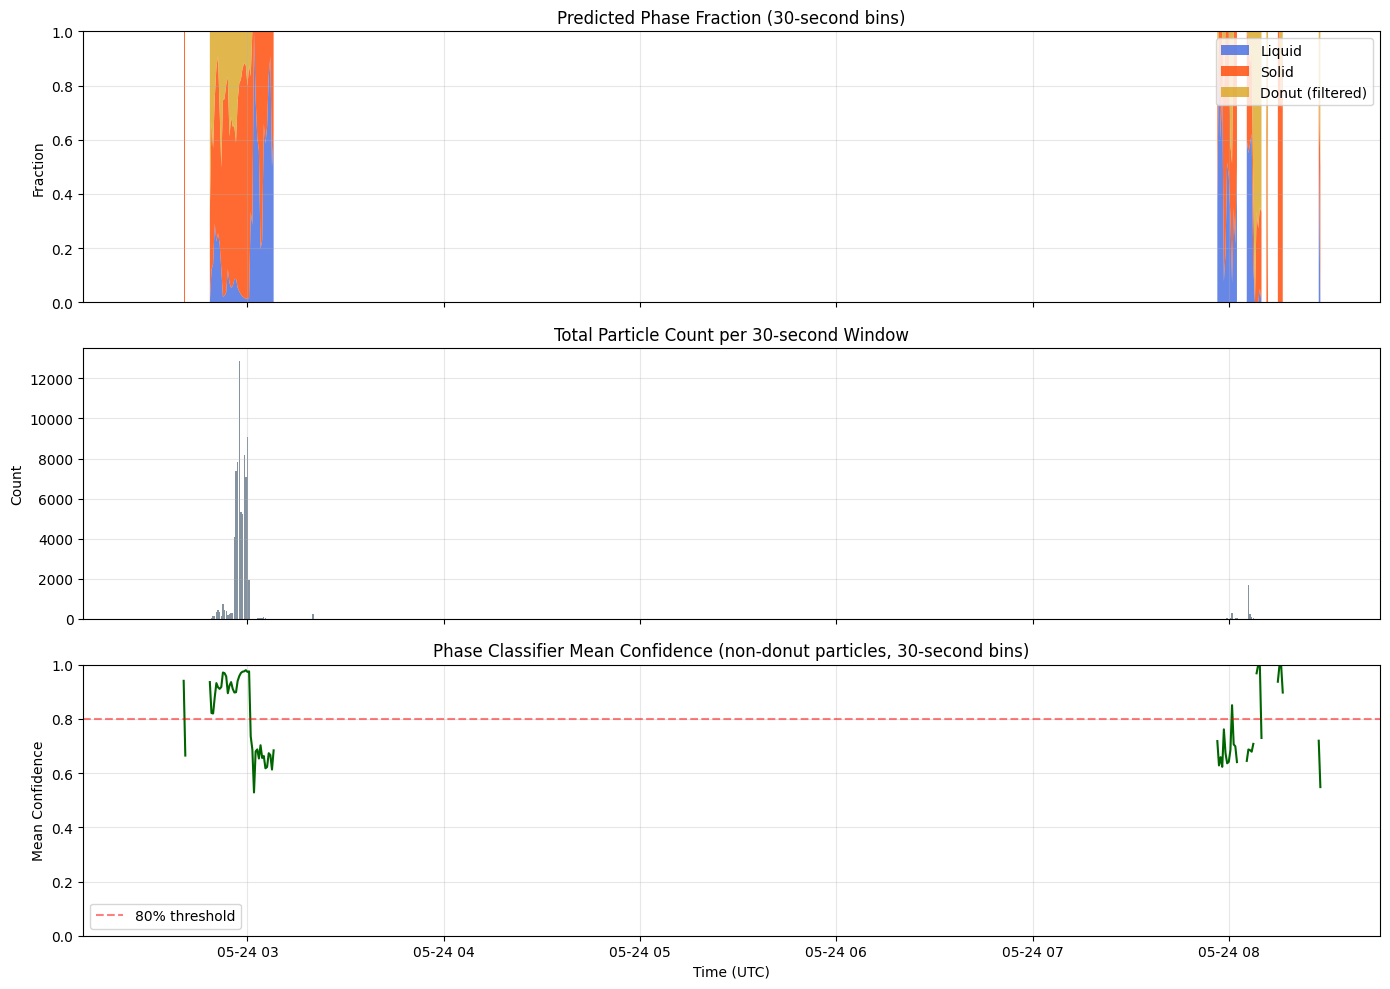

Saved → time_series.png


In [22]:
ts = results_df.set_index('time')

liquid_frac = ts['predicted_phase'].resample('30s').apply(lambda x: (x == 0).mean())
solid_frac  = ts['predicted_phase'].resample('30s').apply(lambda x: (x == 1).mean())
donut_frac  = ts['predicted_phase'].resample('30s').apply(lambda x: (x == 2).mean())
count_ts    = ts['predicted_phase'].resample('30s').count()

# Confidence of the phase classifier only (excludes donut-flagged particles)
phase_conf_series = ts.loc[~ts['predicted_phase'].eq(2), 'confidence']
conf_ts = phase_conf_series.resample('30s').mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Phase fraction
ax = axes[0]
stack_labels = ['Liquid', 'Solid']
stack_values = [liquid_frac.values, solid_frac.values]
stack_colors = ['royalblue', 'orangered']
if DONUT_FILTER:
    stack_labels.append('Donut (filtered)')
    stack_values.append(donut_frac.values)
    stack_colors.append('goldenrod')
ax.stackplot(liquid_frac.index, *stack_values,
             labels=stack_labels, colors=stack_colors, alpha=0.8)
ax.set_ylabel('Fraction')
ax.set_ylim(0, 1)
ax.set_title('Predicted Phase Fraction (30-second bins)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Particle count
axes[1].bar(count_ts.index, count_ts.values,
            width=pd.Timedelta('25s'), color='slategray', alpha=0.85)
axes[1].set_ylabel('Count')
axes[1].set_title('Total Particle Count per 30-second Window')
axes[1].grid(True, alpha=0.3)

# Mean phase-classifier confidence
axes[2].plot(conf_ts.index, conf_ts.values, color='darkgreen', linewidth=1.5)
axes[2].axhline(0.80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
axes[2].set_ylabel('Mean Confidence')
axes[2].set_title('Phase Classifier Mean Confidence (non-donut particles, 30-second bins)')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[2].set_xlabel('Time (UTC)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'time_series.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → time_series.png")

### 8b. Prediction Confidence and Feature Distributions

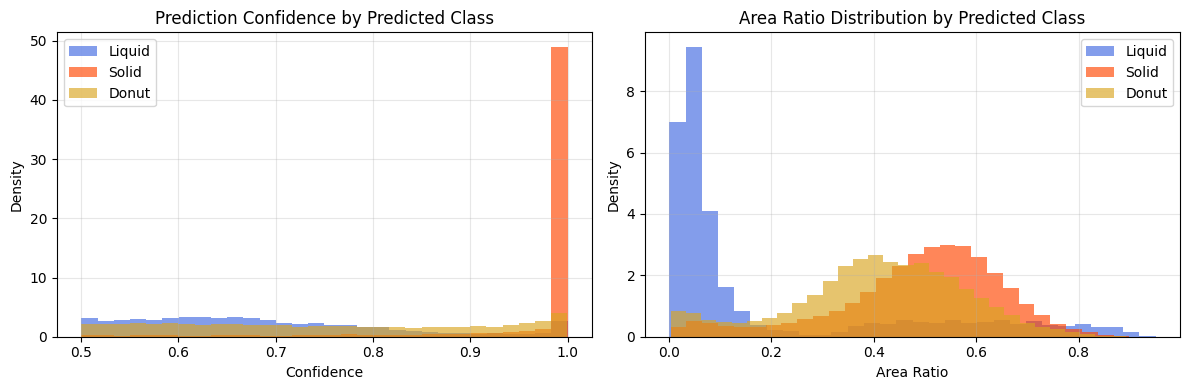

Saved → distributions.png


In [23]:
plot_classes = [('Liquid', 'royalblue'), ('Solid', 'orangered')]
if DONUT_FILTER:
    plot_classes.append(('Donut', 'goldenrod'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in plot_classes:
    mask = results_df['predicted_label'] == label
    if mask.sum() == 0:
        continue
    axes[0].hist(results_df.loc[mask, 'confidence'],
                 bins=30, alpha=0.65, color=color, label=label, density=True)
    axes[1].hist(results_df.loc[mask, 'arearatio'],
                 bins=30, alpha=0.65, color=color, label=label, density=True)

axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Density')
axes[0].set_title('Prediction Confidence by Predicted Class')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Area Ratio')
axes[1].set_ylabel('Density')
axes[1].set_title('Area Ratio Distribution by Predicted Class')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → distributions.png")

### 8c. Sample Particle Gallery (Highest-Confidence Predictions)

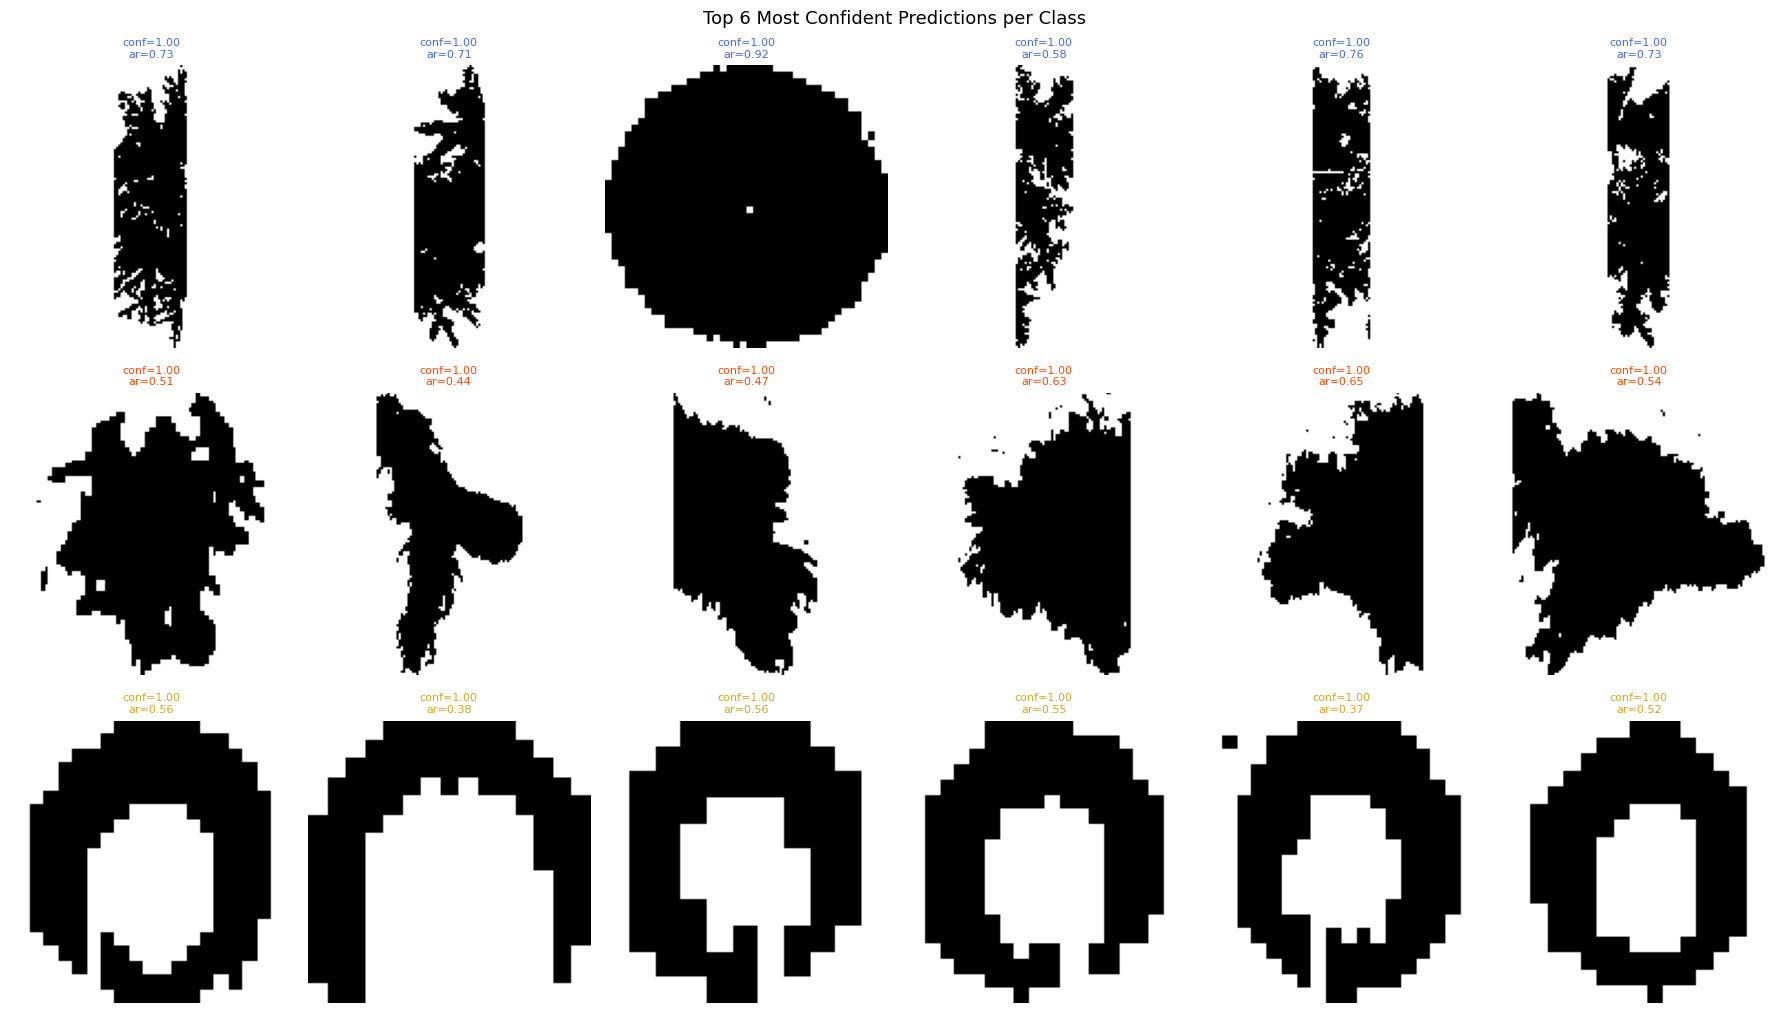

Saved → sample_particles.png


In [24]:
N_SAMPLES = 6

gallery_classes = [(0, 'Liquid', 'royalblue'), (1, 'Solid', 'orangered')]
if DONUT_FILTER and is_donut.sum() > 0:
    gallery_classes.append((2, 'Donut (filtered)', 'goldenrod'))

n_rows = len(gallery_classes)
fig, axes = plt.subplots(n_rows, N_SAMPLES, figsize=(3 * N_SAMPLES, 3.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]   # ensure 2-D indexing

for row_idx, (cls, label, color) in enumerate(gallery_classes):
    cls_idx = np.where(predicted_class == cls)[0]
    if len(cls_idx) == 0:
        for ax in axes[row_idx]:
            ax.axis('off')
        axes[row_idx, 0].set_ylabel(label, fontsize=13, color=color,
                                    rotation=90, labelpad=12)
        continue

    # Sort by confidence descending, take top N_SAMPLES
    top_idx = cls_idx[np.argsort(confidence[cls_idx])[::-1][:N_SAMPLES]]

    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx, col_idx]
        if col_idx < len(top_idx):
            idx = top_idx[col_idx]
            ax.imshow(images[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            ax.set_title(
                f"conf={confidence[idx]:.2f}\nar={arearatios[idx]:.2f}",
                fontsize=8, color=color
            )
            ax.set_xlabel(
                pd.to_datetime(times[idx]).strftime('%H:%M:%S'), fontsize=7
            )
        ax.axis('off')

    axes[row_idx, 0].set_ylabel(label, fontsize=13, color=color,
                                 rotation=90, labelpad=12)

fig.suptitle(f'Top {N_SAMPLES} Most Confident Predictions per Class', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_particles.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sample_particles.png")

## 9. (Optional) Evaluate Against Temperature-Based Labels

Set `HAS_GROUND_TRUTH = True` and provide `NEW_ENV_FILE` if your new flight has
a warm segment (≥ 1 °C) and cold segment (≤ −40 °C) suitable as ground truth.

Particles in the mixed-phase region and donut-flagged particles are excluded
from this evaluation.

In [ ]:
if HAS_GROUND_TRUTH:
    from sklearn.metrics import (classification_report, confusion_matrix,
                                  ConfusionMatrixDisplay, balanced_accuracy_score)

    print("Loading environmental data ...")
    ds_env = xr.open_dataset(NEW_ENV_FILE, decode_times=True)

    liq_mask_env = ds_env.ATX >= LIQUID_TEMP_THRESHOLD
    sol_mask_env = ds_env.ATX <= SOLID_TEMP_THRESHOLD
    liq_cutoff   = ds_env.isel(Time=liq_mask_env.values)['Time'].max().values
    sol_cutoff   = ds_env.isel(Time=sol_mask_env.values)['Time'].min().values

    print(f"  Liquid cutoff (last warm time) : {liq_cutoff}")
    print(f"  Solid  cutoff (first cold time): {sol_cutoff}")

    liq_cutoff_ts = pd.Timestamp(liq_cutoff)
    sol_cutoff_ts = pd.Timestamp(sol_cutoff)

    eval_df = results_df.copy()
    # Restrict to particles in clearly warm or cold segments only
    liq_rows = eval_df['time'] <= liq_cutoff_ts
    sol_rows = eval_df['time'] >= sol_cutoff_ts
    eval_df  = eval_df[liq_rows | sol_rows].copy()
    eval_df['true_phase'] = np.where(eval_df['time'] <= liq_cutoff_ts, 0, 1)
    eval_df['true_label'] = eval_df['true_phase'].map({0: 'Liquid', 1: 'Solid'})

    # Exclude donut-flagged particles from accuracy evaluation
    if DONUT_FILTER:
        n_before = len(eval_df)
        eval_df = eval_df[eval_df['predicted_label'] != 'Donut']
        print(f"  Excluded {n_before - len(eval_df):,} donut-flagged particles from evaluation")

    y_true = eval_df['true_phase'].values
    y_pred = eval_df['predicted_phase'].values

    print(f"\nEvaluating on {len(eval_df):,} particles with temperature labels ...")
    print(f"  Liquid : {(y_true == 0).sum():,}")
    print(f"  Solid  : {(y_true == 1).sum():,}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Liquid', 'Solid']))
    print(f"Balanced accuracy : {balanced_accuracy_score(y_true, y_pred):.4f}")

    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Liquid', 'Solid'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix\n(Temperature Labels vs. Model Predictions)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → confusion_matrix.png")

    out_eval = os.path.join(OUTPUT_DIR, 'particle_phase_predictions_evaluated.csv')
    eval_df.to_csv(out_eval, index=False)
    print(f"Evaluated results saved → {out_eval}")

else:
    print("Skipping evaluation (HAS_GROUND_TRUTH = False).")
    print("Set HAS_GROUND_TRUTH = True in the configuration cell to enable this section.")

## 10. Write Results Back to NetCDF

Adds three new variables to each original PBP netCDF file and saves a `_classified.nc` copy:

| Variable | Type | Description |
|---|---|---|
| `phase_predicted` | int8 | 0=Liquid, 1=Solid, 2=Donut, -1=Excluded by quality filter |
| `phase_prob_liquid` | float32 | P(Liquid) from phase classifier; NaN for excluded/donut particles |
| `phase_prob_solid` | float32 | P(Solid) from phase classifier; NaN for excluded/donut particles |

Particles removed by the heuristic quality filter or by the CNN donut filter receive
fill values (`-1` / `NaN`) so the Time dimension of the output file matches the input exactly.

In [25]:
classified_files = []

for pbp_file in NEW_PBP_FILES:
    if not os.path.exists(pbp_file):
        continue

    probe_name = Path(pbp_file).stem.split('_')[-1]   # e.g. 'V' or 'H'
    probe_mask = probes == probe_name

    # Predictions for this probe
    p_ids        = particle_ids[probe_mask]       # original 0-based indices into ds
    p_phase      = predicted_class[probe_mask]    # 0=Liquid 1=Solid 2=Donut
    p_prob_liq   = phase_probs[probe_mask, 0]
    p_prob_solid = phase_probs[probe_mask, 1]

    # Donut-flagged particles have phase_probs=[0,0] which is not meaningful —
    # replace with NaN so they are indistinguishable from excluded particles.
    donut_mask_probe = p_phase == 2
    p_prob_liq[donut_mask_probe]   = np.nan
    p_prob_solid[donut_mask_probe] = np.nan

    # Re-open original file to get full particle count
    ds_out = xr.open_dataset(pbp_file, decode_times=False)
    n_time = ds_out.dims['Time']

    # Initialise output arrays with fill values
    # -1 = excluded (quality filter) or not reached (image extraction failed)
    phase_arr     = np.full(n_time, -1,     dtype=np.int8)
    prob_liq_arr  = np.full(n_time, np.nan, dtype=np.float32)
    prob_sol_arr  = np.full(n_time, np.nan, dtype=np.float32)

    # Write predictions at the original particle positions
    phase_arr[p_ids]    = p_phase.astype(np.int8)
    prob_liq_arr[p_ids] = p_prob_liq
    prob_sol_arr[p_ids] = p_prob_solid

    # Attach new variables
    ds_out = ds_out.assign({
        'phase_predicted':   ('Time', phase_arr),
        'phase_prob_liquid': ('Time', prob_liq_arr),
        'phase_prob_solid':  ('Time', prob_sol_arr),
    })

    ds_out['phase_predicted'].attrs = {
        'long_name':     'Predicted particle phase',
        'flag_values':   '-1 0 1 2',
        'flag_meanings': 'excluded_by_filter liquid solid donut_artifact',
        'comment':       '-1 = removed by heuristic quality filter or CNN donut filter',
    }
    ds_out['phase_prob_liquid'].attrs = {
        'long_name': 'Model probability of liquid phase',
        'units':     '1',
        'comment':   'NaN for particles excluded by quality filter or flagged as donut',
    }
    ds_out['phase_prob_solid'].attrs = {
        'long_name': 'Model probability of solid (ice) phase',
        'units':     '1',
        'comment':   'NaN for particles excluded by quality filter or flagged as donut',
    }

    # Save — use explicit encoding to control dtypes and fill values
    out_path = Path(OUTPUT_DIR) / (Path(pbp_file).stem + '_classified.nc')
    encoding = {
        'phase_predicted':   {'dtype': 'int8',    '_FillValue': np.int8(-1)},
        'phase_prob_liquid': {'dtype': 'float32', '_FillValue': np.float32('nan')},
        'phase_prob_solid':  {'dtype': 'float32', '_FillValue': np.float32('nan')},
    }
    ds_out.to_netcdf(str(out_path), encoding=encoding)
    ds_out.close()
    classified_files.append(out_path)

    # Per-probe summary
    n_liquid   = int((phase_arr == 0).sum())
    n_solid    = int((phase_arr == 1).sum())
    n_donut    = int((phase_arr == 2).sum())
    n_excluded = int((phase_arr == -1).sum())
    print(f"Probe {probe_name}  →  {out_path.name}")
    print(f"  Total Time steps : {n_time:,}")
    print(f"  Liquid           : {n_liquid:,}")
    print(f"  Solid            : {n_solid:,}")
    print(f"  Donut (filtered) : {n_donut:,}")
    print(f"  Excluded         : {n_excluded:,}")
    print()

print("Classified NetCDF files:")
for f in classified_files:
    size_mb = f.stat().st_size / 1024 ** 2
    print(f"  {f.name:<55}  {size_mb:.1f} MB")

/tmp/ipykernel_2916/2000960803.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_time = ds_out.dims['Time']


Probe V.pbp  →  20250524_022503_F2DS_V.pbp_classified.nc
  Total Time steps : 3,754,562
  Liquid           : 4,565
  Solid            : 56,128
  Donut (filtered) : 16,015
  Excluded         : 3,677,854

Classified NetCDF files:
  20250524_022503_F2DS_V.pbp_classified.nc                 165.5 MB


---
## 11. Quick Particle Viewer (Standalone)

Randomly plots liquid and solid particles from the saved predictions CSV.

**To use after closing the notebook:** run cells 2 (Configuration) and 3 (Helper Functions) only, then run this cell. The full inference pipeline does not need to be re-run.

Loaded 76,708 predictions from /content/drive/MyDrive/GEOG5100/aircraft_ml/inference_results/particle_phase_predictions.csv
predicted_label
Solid     56128
Donut     16015
Liquid     4565
  Loading 20250524_022503_F2DS_V.pbp.nc ...


/tmp/ipykernel_936/1302169799.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.assign_coords(particle_idx_seq=("Time", np.arange(ds.dims["Time"])))
/tmp/ipykernel_936/1302169799.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"    → {ds.dims['Time']:,} particles")


    → 3,754,562 particles
  Loading 20250524_022503_F2DS_V.pbp.nc ...


/tmp/ipykernel_936/1302169799.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.assign_coords(particle_idx_seq=("Time", np.arange(ds.dims["Time"])))
/tmp/ipykernel_936/1302169799.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"    → {ds.dims['Time']:,} particles")


    → 3,754,562 particles


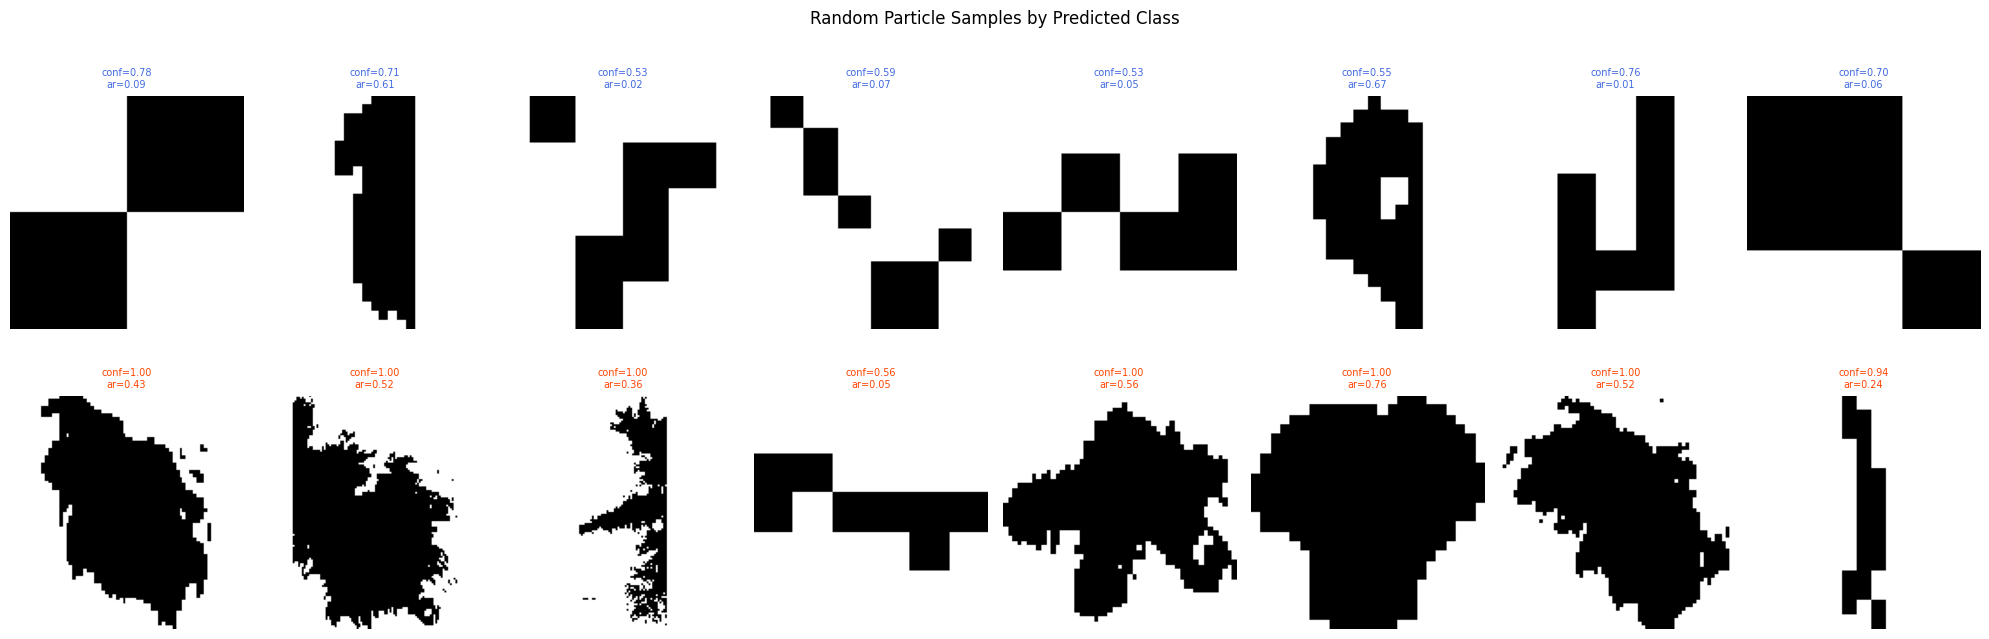

In [5]:
import random as _random

N_SAMPLES   = 8   # particles to show per class
RANDOM_SEED_VIZ = None  # set to an int for a reproducible sample, None for random each run

# ── Load saved predictions ────────────────────────────────────────────────────
_csv_path = os.path.join(OUTPUT_DIR, 'particle_phase_predictions.csv')
assert os.path.exists(_csv_path), (
    f"Predictions CSV not found: {_csv_path}\n"
    "Run the inference pipeline (sections 4-7) at least once first."
)
pred_df = pd.read_csv(_csv_path)
print(f"Loaded {len(pred_df):,} predictions from {_csv_path}")
print(pred_df['predicted_label'].value_counts().to_string())

# ── Map probe name → original PBP file ───────────────────────────────────────
probe_file_map = {
    Path(f).stem.split('_')[-1]: f
    for f in NEW_PBP_FILES
    if os.path.exists(f)
}

# ── Sample and plot ───────────────────────────────────────────────────────────
classes_to_plot = [(0, 'Liquid', 'royalblue'), (1, 'Solid', 'orangered')]
rng = _random.Random(RANDOM_SEED_VIZ)

fig, axes = plt.subplots(
    len(classes_to_plot), N_SAMPLES,
    figsize=(2.5 * N_SAMPLES, 3.5 * len(classes_to_plot))
)

for row_idx, (phase, label, color) in enumerate(classes_to_plot):
    subset  = pred_df[pred_df['predicted_phase'] == phase]
    samples = subset.sample(
        min(N_SAMPLES, len(subset)),
        random_state=rng.randint(0, 99999)
    ).reset_index(drop=True)

    # Group by probe so each netCDF is opened once
    images_by_pid = {}
    for probe_name, group in samples.groupby('probe'):
        if probe_name not in probe_file_map:
            print(f"  WARNING: probe '{probe_name}' file not found, skipping.")
            continue
        ds = load_pbp_data(probe_file_map[probe_name], FLIGHT_DATE)
        for _, row in group.iterrows():
            img = extract_particle_image(ds, int(row['particle_id']))
            if img is not None:
                images_by_pid[int(row['particle_id'])] = img
        ds.close()

    for col in range(N_SAMPLES):
        ax = axes[row_idx, col]
        if col < len(samples):
            pid  = int(samples.loc[col, 'particle_id'])
            conf = samples.loc[col, 'confidence']
            ar   = samples.loc[col, 'arearatio']
            if pid in images_by_pid:
                ax.imshow(images_by_pid[pid], cmap='gray')
                ax.set_title(
                    f"conf={conf:.2f}\nar={ar:.2f}",
                    fontsize=7, color=color
                )
        ax.axis('off')

    axes[row_idx, 0].set_ylabel(label, fontsize=12, color=color,
                                rotation=90, labelpad=10)

plt.suptitle('Random Particle Samples by Predicted Class', fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary of Outputs

| File | Description |
|------|-------------|
| `inference_results/particle_phase_predictions.csv` | Per-particle predictions. `predicted_phase`: 0=Liquid, 1=Solid, 2=Donut. When `DONUT_FILTER=True`, also includes `is_donut` and `donut_prob` columns. |
| `inference_results/time_series.png` | Phase fraction (Liquid/Solid/Donut), particle count, and phase-classifier confidence over time |
| `inference_results/distributions.png` | Confidence and area ratio distributions by predicted class |
| `inference_results/sample_particles.png` | Gallery of highest-confidence predictions per class (includes Donut row when filter is active) |
| `inference_results/confusion_matrix.png` | *(Optional)* Accuracy vs. temperature labels (donut-flagged particles excluded) |
| `inference_results/particle_phase_predictions_evaluated.csv` | *(Optional)* Predictions with ground-truth labels attached |